In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from prophet import Prophet


In [2]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [3]:
print("Shape:", df.shape)

Shape: (2640, 12)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,2640.0,2020.000000,3.162877,2015.00,2017.000,2020.000,2023.0000,2025.00
Month,2640.0,6.500000,3.452707,1.00,3.750,6.500,9.2500,12.00
Estimated_Deliveries,2640.0,9922.199621,3935.950093,48.00,7292.000,9857.000,12510.2500,25704.00
Production_Units,2640.0,10655.847348,4260.600858,50.00,7828.250,10546.500,13469.0000,28939.00
Avg_Price_USD,2640.0,84907.340330,20123.258036,50003.70,67726.365,85058.510,102373.0425,119965.36
Battery_Capacity_kWh,2640.0,87.059470,20.836265,60.00,75.000,82.000,100.0000,120.00
Range_km,2640.0,500.257576,120.868549,330.00,418.000,470.000,586.2500,719.00
CO2_Saved_tons,2640.0,744.076989,353.221224,3.07,499.620,699.515,943.7650,2548.55
Charging_Stations,2640.0,8932.133712,3469.565883,3002.00,5897.750,8901.500,11938.0000,14996.00


In [6]:
df.isnull().sum().sort_values(ascending=False)  #It is used to find the number null values present in every columns

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [7]:
print("Duplicates:", df.duplicated().sum())


df = df.drop_duplicates()

Duplicates: 0


In [8]:
#We need to create datetime because we need it for forecasting
df["Date"] = pd.to_datetime(   
    dict(
        year=df["Year"],
        month=df["Month"],
        day=1
    )
)

df.head()    

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,2023-05-01
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,2015-02-01
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,2019-01-01
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,2021-02-01
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,2016-12-01


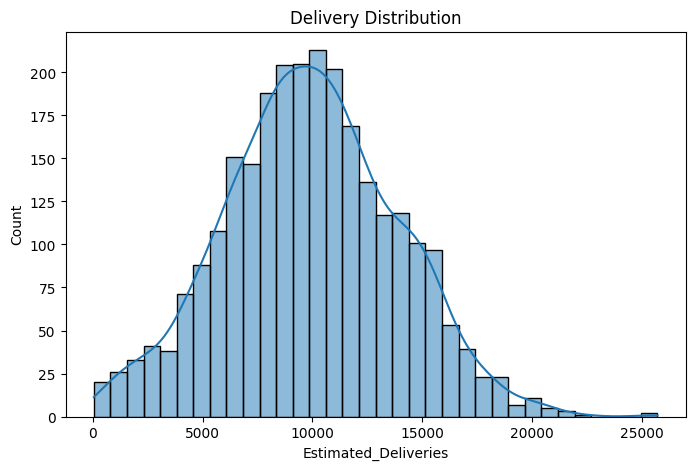

In [9]:
#Target Distribution

plt.figure(figsize=(8,5))
sns.histplot(
    df["Estimated_Deliveries"],
    kde=True
)

plt.title("Delivery Distribution")
plt.show()

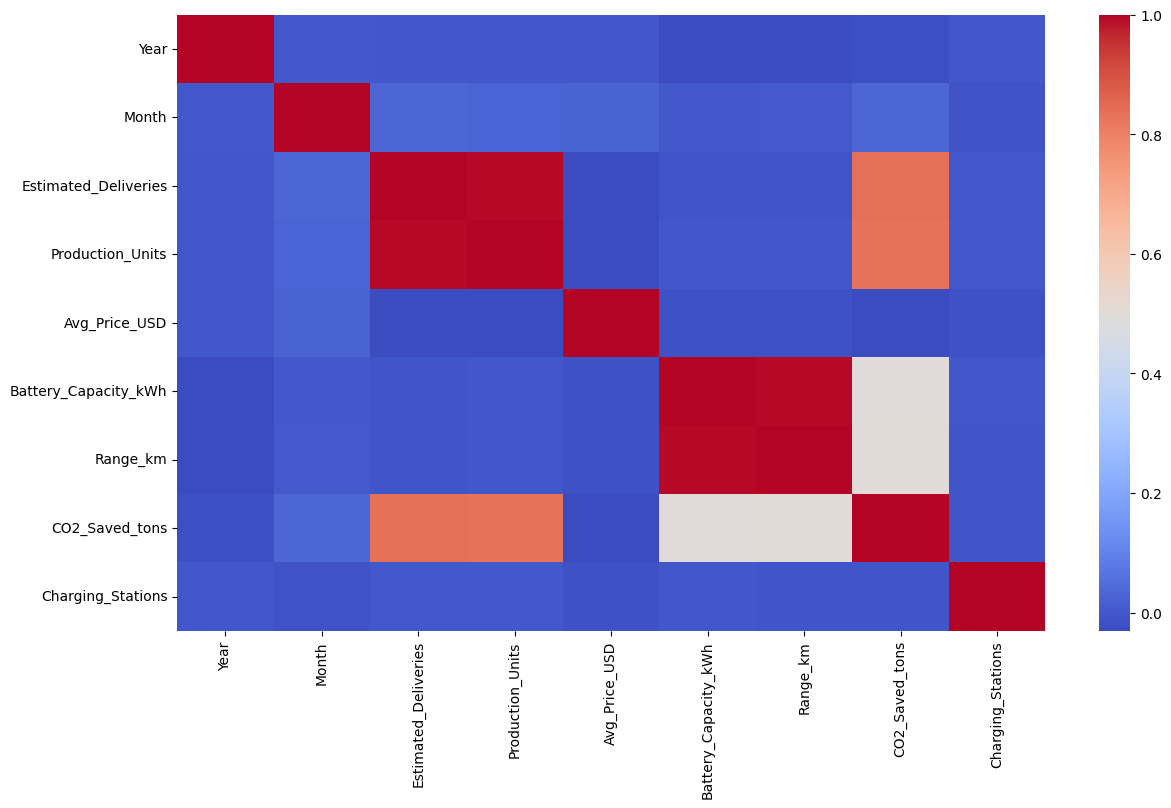

In [10]:
## Correlation Analysis --- it is used to identify important numerical drivers

corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(14,8))
sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False
)
plt.show()


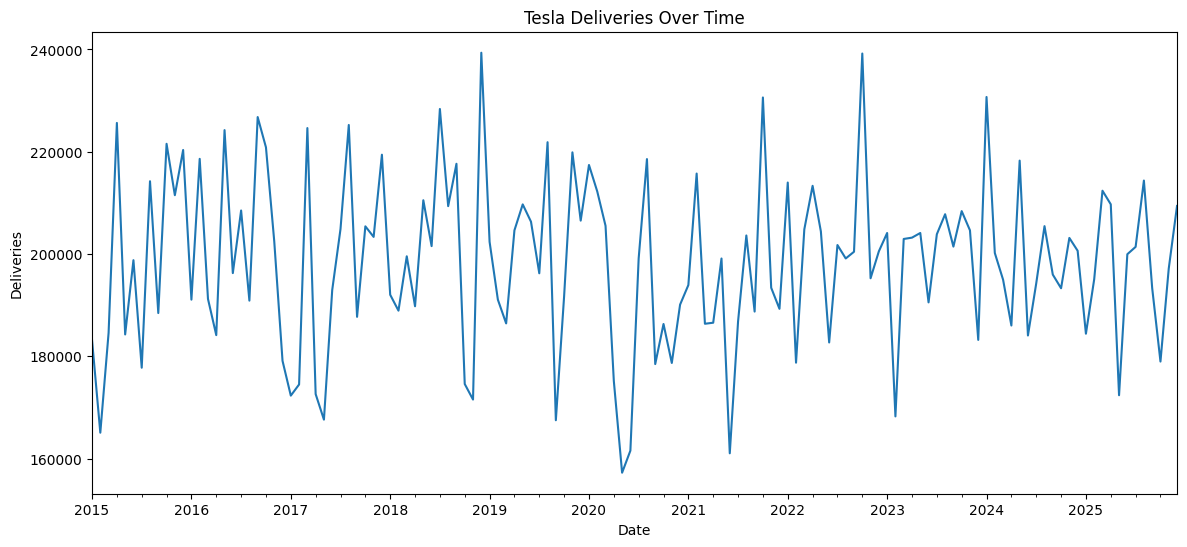

In [11]:
#Monthly Trend 

monthly = (
    df.groupby("Date")
    ["Estimated_Deliveries"]
    .sum()
)

plt.figure(figsize=(14,6))
monthly.plot()
plt.title("Tesla Deliveries Over Time")
plt.ylabel("Deliveries")

plt.show()

### Feature Engineering

In [12]:
df["Price_per_kWh"] = (df["Avg_Price_USD"] / df["Battery_Capacity_kWh"])

df["Range_per_kWh"] = (df["Range_km"] / df["Battery_Capacity_kWh"])

# We perform Feature Engineering Because Raw features don't capture operational efficiency and Ratios often provide stronger predictive power


In [13]:
df["Month_Sin"] = np.sin(2*np.pi*df["Month"]/12)

df["Month_Cos"] = np.cos(2*np.pi*df["Month"]/12)

# We Often perform this because December and january are close in time .So, Integer encoding cannot represent this relationship

In [14]:
## Defining Features

X = df.drop(columns=["Estimated_Deliveries", "Date", "Production_Units"])

y = df["Estimated_Deliveries"]


In [15]:
numerical_features = X.select_dtypes(include=["int64","float64"]).columns

categorical_features = X.select_dtypes(include=["object"]).columns  

#We only consider the columns when ther data type are integer and float for input 

## Preprocessing Pipeline



In [16]:
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

preprocessor = ColumnTransformer([
    (
        "num",
        numeric_pipeline,
        numerical_features
    ),
    (
        "cat",
        categorical_pipeline,
        categorical_features
    )
])

###  Train Test Split


In [17]:
split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]


### Model pipeline

In [18]:
pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        RandomForestRegressor(
            random_state=42
        )
    )
])

# I have choosen RandomForeset Model here Because :
#                  It captures non linear Relationships
#                   Requires minimal feature assumptions
#                   Strong baseline for tabular business data

### HyperParameter Tuning

In [19]:
params = {
    "model__n_estimators":
        [100,200,300,500],

    "model__max_depth":
        [5,10,15,20,None],

    "model__min_samples_split":
        [2,5,10],

    "model__min_samples_leaf":
        [1,2,4]
}

In [20]:
search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=params,
    n_iter=20,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    random_state=42
)

search.fit(
    X_train,
    y_train
)

best_model = search.best_estimator_

# Print the Best CV Score
print("Best CV Score:", abs(search.best_score_))


Best CV Score: 135.7647794665457


In [21]:
preds = best_model.predict(X_test)
preds

array([11973.12502143,  9222.5143619 , 16033.90656508, 10285.90014524,
       15090.20820317,  3781.06698175,  8352.36033254,  4339.9864619 ,
        3076.14537063,  8197.17279762, 14085.30210952,  7602.46883102,
       13698.33187143, 12131.06282143, 12263.43703254, 10208.3817189 ,
       11577.22193175,  6222.42291667,  7893.69580079, 11236.50991905,
        6006.38697222,  9279.37781212, 13840.24021032, 16381.57624286,
        5493.04988016,  5121.9447254 , 10149.87296234,  9484.48670635,
       20587.69949762, 10283.58799921, 19160.30574762, 13457.2006754 ,
        6842.79538492, 14177.39008968,  3120.94233175, 10312.92616948,
        6384.06507222, 10733.51188889,  9269.43308456, 19212.49696746,
        8741.46770794, 11040.69697273,  8341.31004603, 14295.47589762,
        7838.85459444, 11498.80754286, 14038.85435556,  5051.35582302,
        4009.47910317, 14063.72827619,  3330.90239603,  9938.45403095,
        8197.95242619, 14572.93699603,  9220.65793175,  6475.77232857,
      

In [22]:
#Evaluation Metrics
mae = mean_absolute_error(y_test,preds)

rmse = np.sqrt(mean_squared_error(y_test,preds))

r2 = r2_score(y_test,preds)

print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("R2  :", round(r2,4))

MAE : 111.65
RMSE: 197.94
R2  : 0.9974


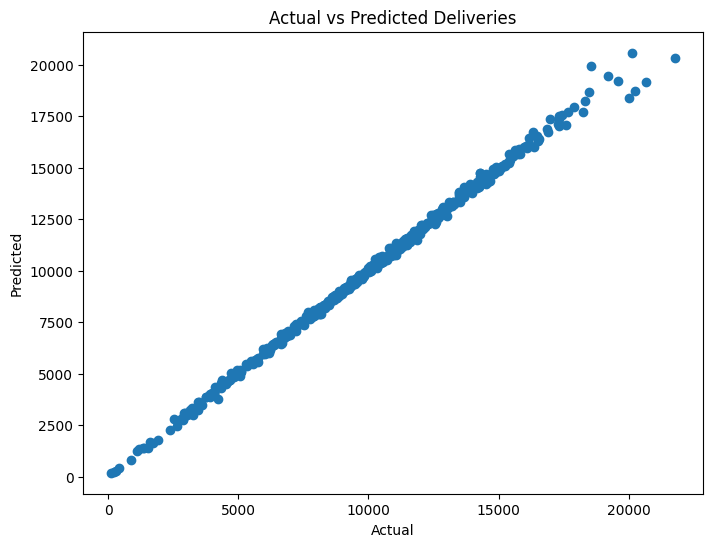

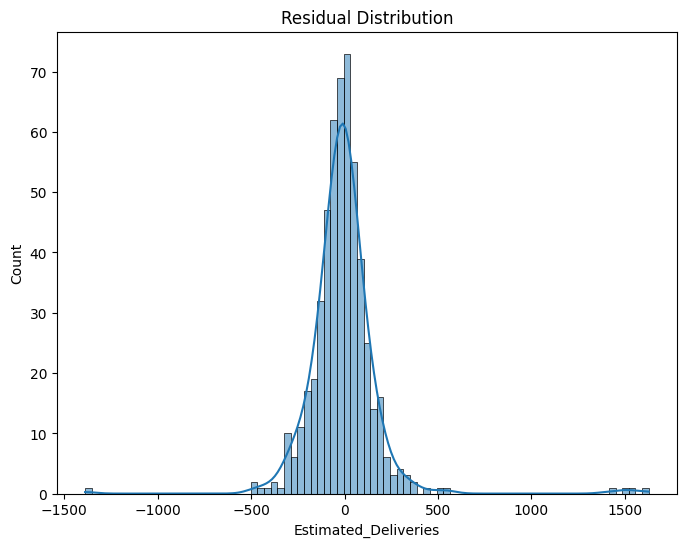

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Actual vs Predicted Plot
plt.figure(figsize=(8,6))
plt.scatter(y_test, preds)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Deliveries")
plt.show()

# Residual Plot
residuals = y_test - preds
plt.figure(figsize=(8,6))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()


In [24]:
## Feature Importance
feature_names = (
    best_model.named_steps["preprocessor"]
    .get_feature_names_out()
)

importance = (
    best_model.named_steps["model"]
    .feature_importances_
)

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

importance_df = (
    importance_df
    .sort_values(
        by="Importance",
        ascending=False
    )
)

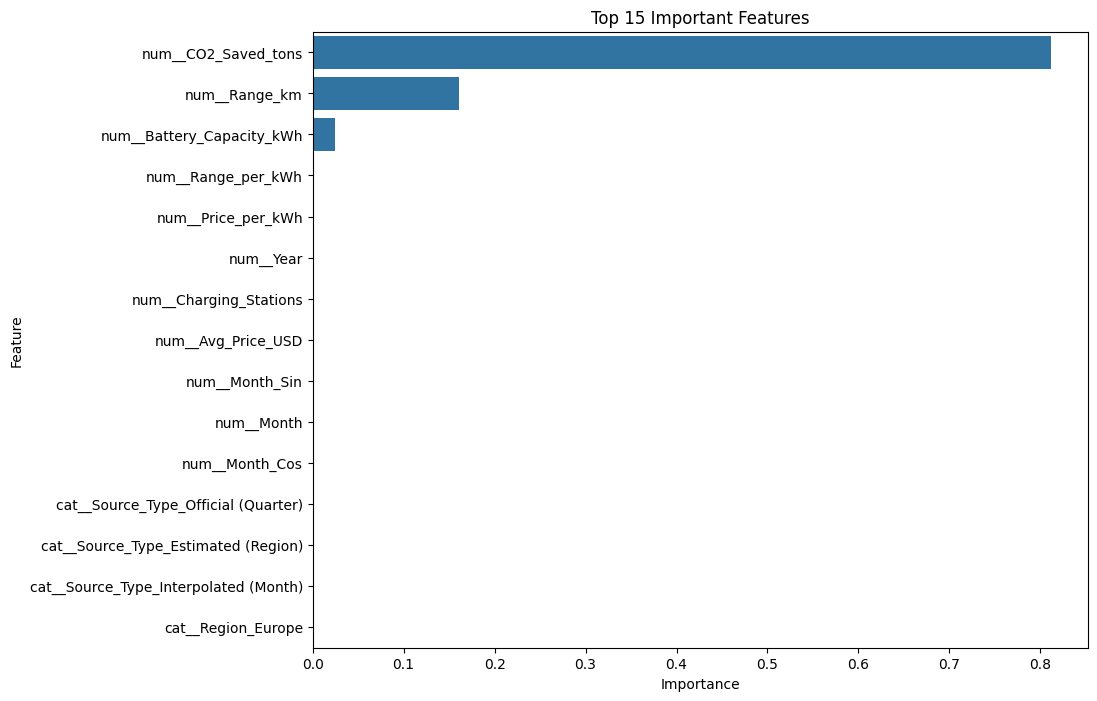

In [25]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=importance_df.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")

plt.show()

###  Time Series Forecasting

In [26]:
ts = (
    df.groupby("Date")["Estimated_Deliveries"]
    .sum()
    .reset_index()
)

ts.columns = ["ds", "y"]

ts.head()

,ds,y
0,2015-01-01,183180
1,2015-02-01,165053
2,2015-03-01,184567
3,2015-04-01,225623
4,2015-05-01,184264


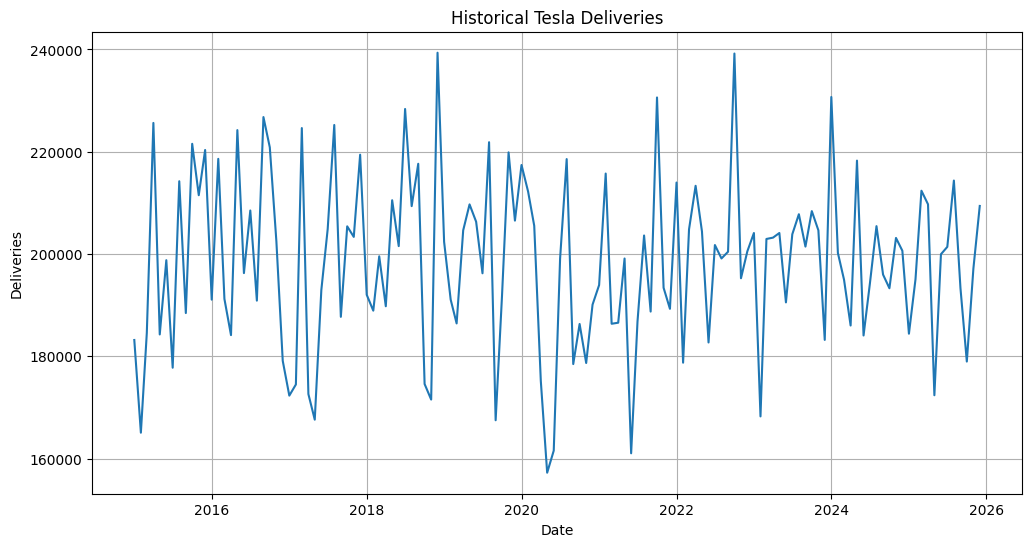

In [27]:
plt.figure(figsize=(12,6))

plt.plot(
    ts["ds"],
    ts["y"]
)

plt.title("Historical Tesla Deliveries")
plt.xlabel("Date")
plt.ylabel("Deliveries")

plt.grid(True)

plt.show()

In [28]:
import joblib

joblib.dump(best_model, "tesla_delivery_model.pkl")


['tesla_delivery_model.pkl']

#### Training Prophet Model



In [29]:
# I have choosen Prophet model because of it automatically handles trend and seasonality, works well on momnthly data and produces future forecasts with confidence intervals

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='additive'
)

model.fit(ts)




08:25:11 - cmdstanpy - INFO - Chain [1] start processing
08:25:11 - cmdstanpy - INFO - Chain [1] done processing


In [30]:
## Generating Future Dates ( forecasting next 12 months)

future = model.make_future_dataframe(
    periods=12,
    freq='ME'
)

future.tail()

,ds
139,2026-07-31
140,2026-08-31
141,2026-09-30
142,2026-10-31
143,2026-11-30


In [31]:
# Predict  future deliveries

forecast = model.predict(future)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2015-01-01,200387.062678,181465.884549,218473.539796,200387.062678,200387.062678,86.042503,86.042503,86.042503,86.042503,86.042503,86.042503,0.0,0.0,0.0,200473.105181
1,2015-02-01,200382.806365,171624.105425,210684.605837,200382.806365,200382.806365,-8918.032602,-8918.032602,-8918.032602,-8918.032602,-8918.032602,-8918.032602,0.0,0.0,0.0,191464.773763
2,2015-03-01,200378.961953,170880.940265,209277.115838,200378.961953,200378.961953,-11079.246578,-11079.246578,-11079.246578,-11079.246578,-11079.246578,-11079.246578,0.0,0.0,0.0,189299.715375
3,2015-04-01,200374.705641,184784.266755,220223.990366,200374.705641,200374.705641,2940.054510,2940.054510,2940.054510,2940.054510,2940.054510,2940.054510,0.0,0.0,0.0,203314.760150
4,2015-05-01,200370.586629,174398.446431,214503.574553,200370.586629,200370.586629,-5615.888601,-5615.888601,-5615.888601,-5615.888601,-5615.888601,-5615.888601,0.0,0.0,0.0,194754.698028


In [32]:
#Forecast Results

forecast[
    [
        "ds",
        "yhat",
        "yhat_lower",
        "yhat_upper"
    ]
].tail(12)

,ds,yhat,yhat_lower,yhat_upper
132,2025-12-31,209804.394715,188889.986988,228791.825600
133,2026-01-31,186950.076010,168202.684023,206975.548674
134,2026-02-28,169719.978189,151393.248975,188486.222554
135,2026-03-31,218481.172341,198327.867217,236865.293302
136,2026-04-30,192259.884072,173824.594588,212406.168683
137,2026-05-31,205046.315100,185712.198398,224315.804443
138,2026-06-30,188981.473520,170233.980279,208405.959909
139,2026-07-31,212996.994624,193519.039563,232921.658824
140,2026-08-31,177713.257679,158527.575169,197823.057512
141,2026-09-30,206754.217323,187322.799562,225504.956066


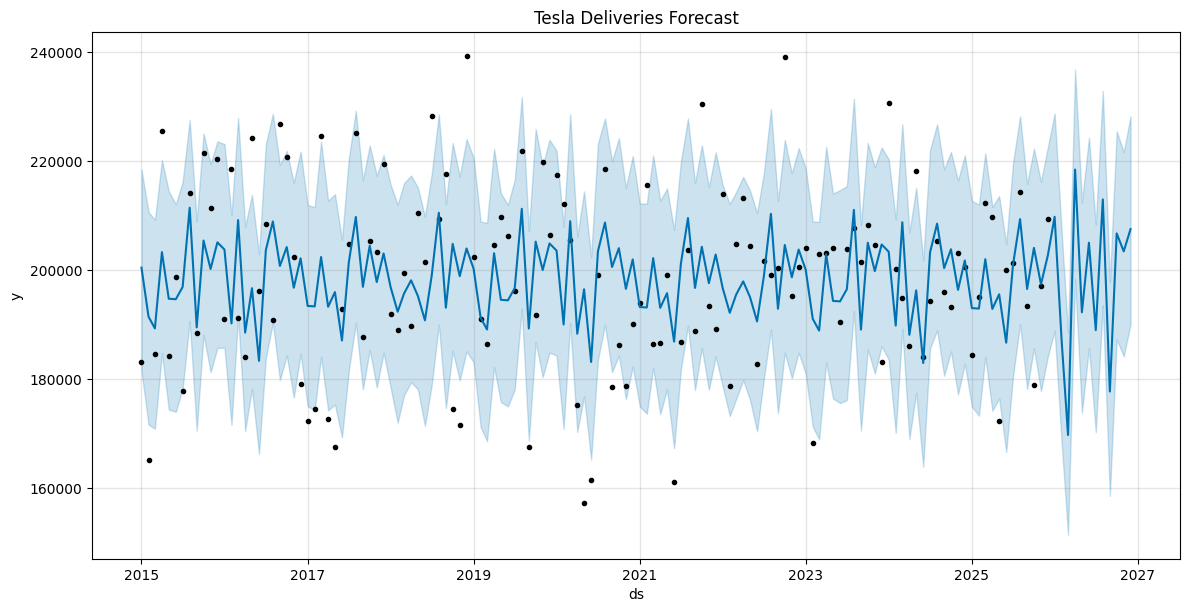

In [33]:
fig = model.plot(
    forecast,
    figsize=(12,6)
)

plt.title("Tesla Deliveries Forecast")

plt.show()

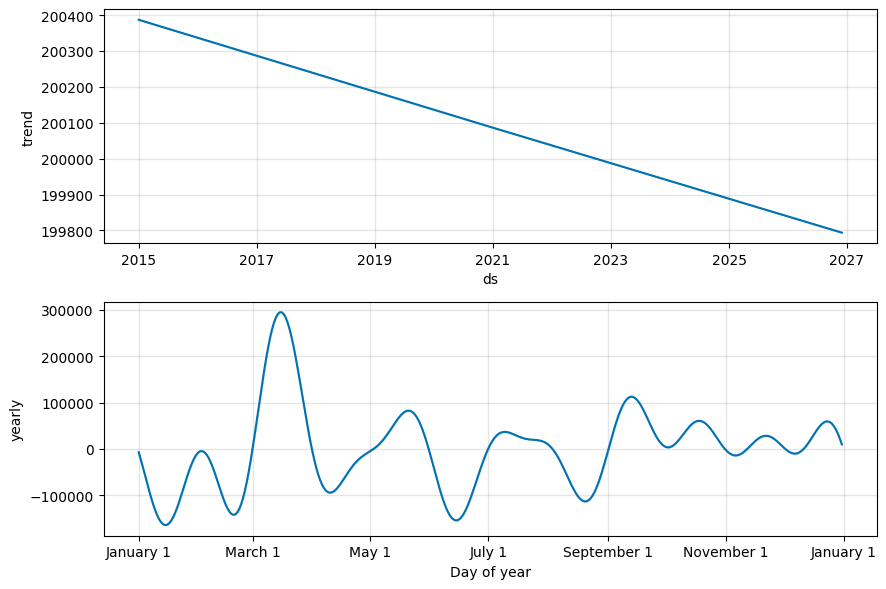

In [34]:
## Trend and seasonality components

fig2 = model.plot_components(
    forecast
)

plt.show()

In [35]:
future_forecast = forecast[
    [
        "ds",
        "yhat",
        "yhat_lower",
        "yhat_upper"
    ]
].tail(12)

future_forecast.to_csv(
    "future_delivery_forecast.csv",
    index=False
)

future_forecast

,ds,yhat,yhat_lower,yhat_upper
132,2025-12-31,209804.394715,188889.986988,228791.825600
133,2026-01-31,186950.076010,168202.684023,206975.548674
134,2026-02-28,169719.978189,151393.248975,188486.222554
135,2026-03-31,218481.172341,198327.867217,236865.293302
136,2026-04-30,192259.884072,173824.594588,212406.168683
137,2026-05-31,205046.315100,185712.198398,224315.804443
138,2026-06-30,188981.473520,170233.980279,208405.959909
139,2026-07-31,212996.994624,193519.039563,232921.658824
140,2026-08-31,177713.257679,158527.575169,197823.057512
141,2026-09-30,206754.217323,187322.799562,225504.956066


In [36]:
print(
    f"""
    Average Forecasted Deliveries:
    {future_forecast['yhat'].mean():,.0f}

    Maximum Forecast:
    {future_forecast['yhat'].max():,.0f}

    Minimum Forecast:
    {future_forecast['yhat'].min():,.0f}
    """
)


    Average Forecasted Deliveries:
    198,309

    Maximum Forecast:
    218,481

    Minimum Forecast:
    169,720
    
